In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    auc,
)

from xgboost import XGBClassifier
import joblib

In [2]:
def resolve_data_path(filename: str) -> str:
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    return filename

DATA_FILE = "global_house_purchase_dataset.csv"
DATA_PATH = resolve_data_path(DATA_FILE)
DATA_PATH

'global_house_purchase_dataset.csv'

In [3]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (200000, 25)


,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,...,10745,193949,15,6545,218986,0.16,1,5,6,0
1,2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,...,16970,181465,20,8605,43073,0.08,9,1,2,0
2,3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,...,21914,307953,30,2510,437151,0.09,6,8,1,0
3,4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,...,17980,674720,15,8805,436239,0.33,2,6,6,0
4,5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,...,17676,65833,25,8965,33208,0.03,3,3,4,0


In [4]:
print("==== INFO ====")
display(df.info())

print("\n==== MISSING (TOP) ====")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20))

print("\nDuplicate rows:", int(df.duplicated().sum()))

print("\n==== TARGET DISTRIBUTION (decision) ====")
display(df["decision"].value_counts(dropna=False))
display((df["decision"].value_counts(normalize=True, dropna=False) * 100).round(2).rename("%"))

==== INFO ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   property_id              200000 non-null  int64  
 1   country                  200000 non-null  object 
 2   city                     200000 non-null  object 
 3   property_type            200000 non-null  object 
 4   furnishing_status        200000 non-null  object 
 5   property_size_sqft       200000 non-null  int64  
 6   price                    200000 non-null  int64  
 7   constructed_year         200000 non-null  int64  
 8   previous_owners          200000 non-null  int64  
 9   rooms                    200000 non-null  int64  
 10  bathrooms                200000 non-null  int64  
 11  garage                   200000 non-null  int64  
 12  garden                   200000 non-null  int64  
 13  crime_cases_reported     200000 non-null  in

None


==== MISSING (TOP) ====


,0



Duplicate rows: 0

==== TARGET DISTRIBUTION (decision) ====


,count
decision,
0,153932
1,46068


,%
decision,
0,76.97
1,23.03


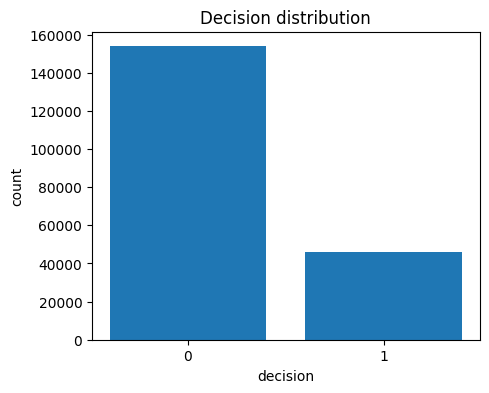

In [5]:
# EDA: phân bố target (bỏ NaN nếu có)
target_clean = df["decision"].dropna()
counts = target_clean.value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Decision distribution")
plt.xlabel("decision")
plt.ylabel("count")
plt.show()

,count,mean,std,min,25%,50%,75%,max
property_id,200000.0,1.000005e+05,57735.171256,1.0,50000.75,100000.50,150000.25,200000.00
property_size_sqft,200000.0,3.195633e+03,1613.322287,400.0,1802.00,3190.00,4589.00,6000.00
price,200000.0,1.215365e+06,823663.258915,56288.0,565989.50,1023429.00,1725556.50,4202732.00
constructed_year,200000.0,1.991488e+03,18.494064,1960.0,1975.00,1991.00,2008.00,2023.00
previous_owners,200000.0,3.001370e+00,2.002198,0.0,1.00,3.00,5.00,6.00
rooms,200000.0,4.513855e+00,2.295669,1.0,3.00,5.00,7.00,8.00
bathrooms,200000.0,2.760030e+00,1.840959,1.0,1.00,2.00,4.00,8.00
garage,200000.0,4.993500e-01,0.500001,0.0,0.00,0.00,1.00,1.00
garden,200000.0,5.002150e-01,0.500001,0.0,0.00,1.00,1.00,1.00
crime_cases_reported,200000.0,1.229065e+00,1.185336,0.0,0.00,1.00,2.00,10.00


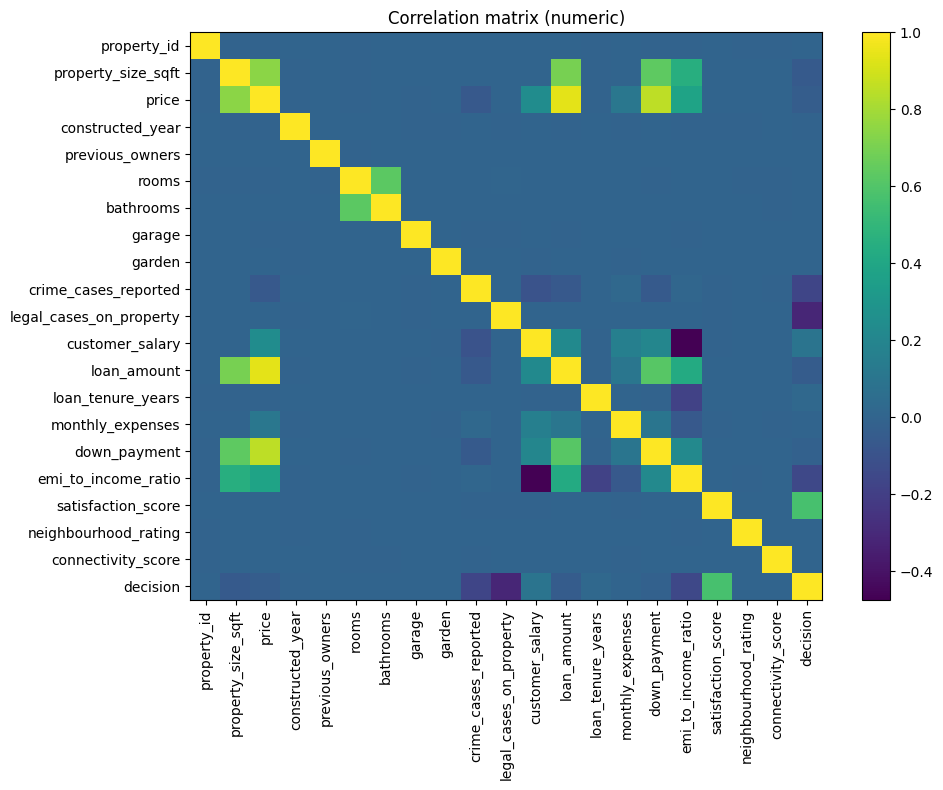

In [6]:
# EDA: thống kê nhanh numeric + correlation (numeric only)
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
display(df[numeric_cols].describe().T)

corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.title("Correlation matrix (numeric)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()

In [7]:
# 1) Chuẩn bị X/y (giống RF)
TARGET = "decision"

# Guard: nếu decision có NaN thì drop các dòng đó (không ảnh hưởng nếu file sạch)
df_model = df.dropna(subset=[TARGET]).copy()

X = df_model.drop(columns=[TARGET], errors="ignore").copy()
y = df_model[TARGET].copy()

# ép target về int (0/1) an toàn
y = pd.to_numeric(y, errors="coerce")
mask = ~y.isna()
X = X.loc[mask].copy()
y = y.loc[mask].astype(int)

# Loại bỏ cột định danh nếu có
X = X.drop(columns=["property_id"], errors="ignore")

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols)
print("X shape:", X.shape, "| y shape:", y.shape)
print("y value counts:")
print(y.value_counts())

Categorical cols: ['country', 'city', 'property_type', 'furnishing_status']
Numeric cols: ['property_size_sqft', 'price', 'constructed_year', 'previous_owners', 'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported', 'legal_cases_on_property', 'customer_salary', 'loan_amount', 'loan_tenure_years', 'monthly_expenses', 'down_payment', 'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating', 'connectivity_score']
X shape: (200000, 23) | y shape: (200000,)
y value counts:
decision
0    153932
1     46068
Name: count, dtype: int64


In [8]:
# 2) Train/Test split (stratify giống RF)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (160000, 23) (160000,)
Test : (40000, 23) (40000,)


In [9]:
# 3) Tiền xử lý (giống RF)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop",
)

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['property_size_sqft', 'price',
                                  'constructed_year', 'previous_owners',
                                  'rooms', 'bathrooms', 'garage', 'garden',
                                  'crime_cases_reported',
                                  'legal_cases_on_property', 'customer_salary',
                                  'loan_amount', 'loan_tenure_years',
                                  'monthly_expenses', 'down_payment',
                                  'emi_to_income_ratio', 'satisfaction_score',
                                  'neighbourhood_rating',
                                  'connectivity_score']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['country', 'city', 'property_type',
                                  'furnishing_status'])])

In [10]:
# 4) XGBoost model (tham số theo mẫu XGBoost + hợp lý cho classification)
# scale_pos_weight để hỗ trợ imbalance (nếu có)
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("xgb", xgb),
])

pipe

scale_pos_weight: 3.3414554729473056


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['property_size_sqft',
                                                   'price', 'constructed_year',
                                                   'previous_owners', 'rooms',
                                                   'bathrooms', 'garage',
                                                   'garden',
                                                   'crime_cases_reported',
                                                   'legal_cases_on_property',
                                                   'customer_salary',
                                                   'loan_amount',
                                                   'loan_tenure_years',
                                                   'monthly_expenses'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=600, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [11]:
# 5) Train
pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['property_size_sqft',
                                                   'price', 'constructed_year',
                                                   'previous_owners', 'rooms',
                                                   'bathrooms', 'garage',
                                                   'garden',
                                                   'crime_cases_reported',
                                                   'legal_cases_on_property',
                                                   'customer_salary',
                                                   'loan_amount',
                                                   'loan_tenure_years',
                                                   'monthly_expenses'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=600, n_jobs=-1,
                               num_parallel_tree=None, ...))])

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     30786
           1     1.0000    1.0000    1.0000      9214

    accuracy                         1.0000     40000
   macro avg     1.0000    1.0000    1.0000     40000
weighted avg     1.0000    1.0000    1.0000     40000



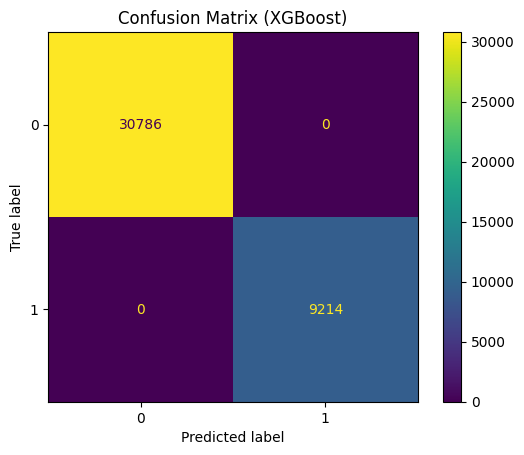

ROC-AUC: 1.0


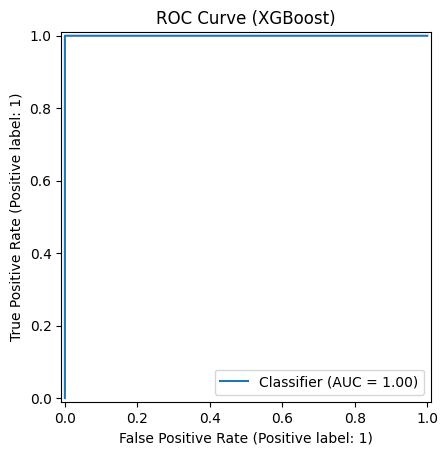

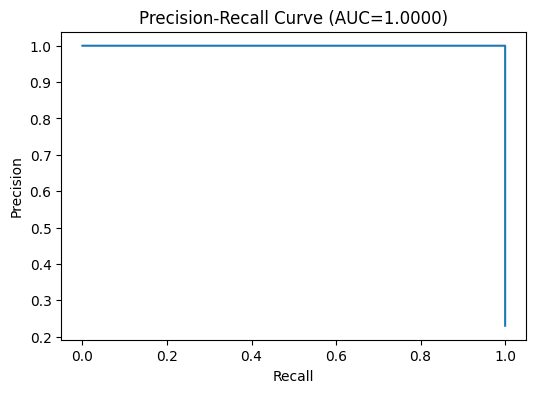

In [12]:
# 6) Evaluate
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix (XGBoost)")
plt.show()

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", round(float(roc_auc), 6))

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve (XGBoost)")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve (AUC={pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## Feature importance (Top 20)

Vì có OneHotEncoder nên số feature sau preprocess sẽ tăng. Cell dưới sẽ lấy tên feature sau preprocess và map với `feature_importances_` của XGBoost.


,feature,importance
16,num__satisfaction_score,0.610972
9,num__legal_cases_on_property,0.258457
15,num__emi_to_income_ratio,0.061496
8,num__crime_cases_reported,0.045407
11,num__loan_amount,0.006243
10,num__customer_salary,0.004232
1,num__price,0.001916
31,cat__country_USA,0.001095
20,cat__country_Brazil,0.000847
28,cat__country_South Africa,0.000792


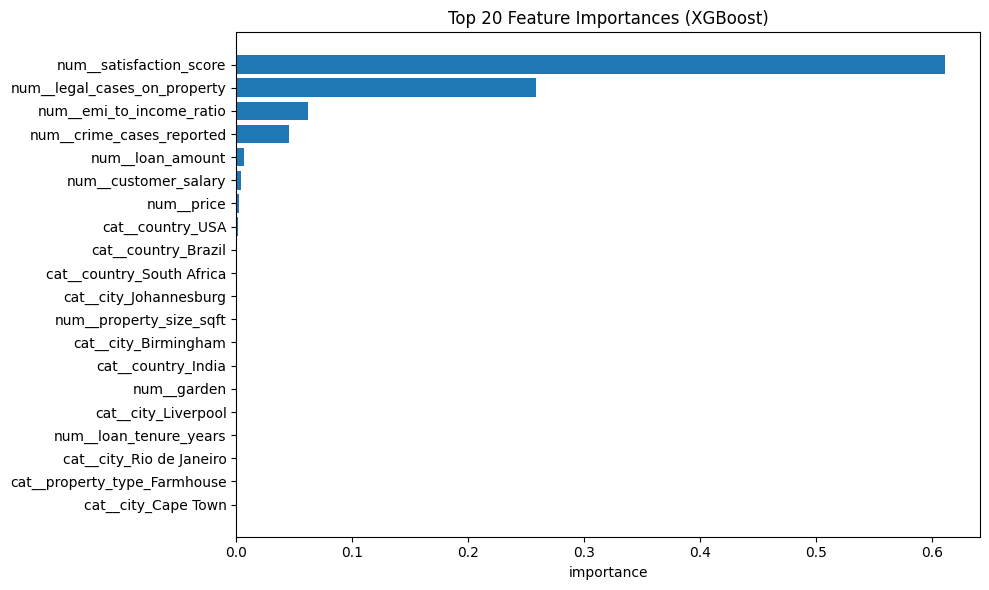

In [13]:
# Feature names sau preprocess
prep = pipe.named_steps["prep"]
model = pipe.named_steps["xgb"]

try:
    feature_names = prep.get_feature_names_out()
except Exception:
    # fallback nếu sklearn version không hỗ trợ
    # vẫn hiển thị theo index
    n_features = model.feature_importances_.shape[0]
    feature_names = np.array([f"f{i}" for i in range(n_features)])

importances = model.feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
)

display(fi.head(30))

top = fi.head(20).iloc[::-1]
plt.figure(figsize=(10,6))
plt.barh(top["feature"].astype(str), top["importance"])
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

## Lưu model pipeline

Lưu cả `preprocess` + `xgb` trong 1 file để dùng dự đoán lại sau này.


In [14]:
MODEL_PATH = "house_purchase_xgb_pipeline.joblib"
joblib.dump(pipe, MODEL_PATH)
MODEL_PATH

'house_purchase_xgb_pipeline.joblib'